# Notebook 07 — Performance Battery & Signal-Improvement Experiments

Three desk requests (2026-07-24, after the desk configuration shipped):

1. **"Give me more performance metrics"** — grounded in the published
   evaluation literature, not invented in-house. Part A below runs a
   battery of standard measures, each with its source named:
   event-study cumulative abnormal returns (MacKinlay 1997), the
   information coefficient (Grinold & Kahn 2000), precision–recall
   analysis for rare-event detection (Davis & Goadrich 2006; Saito &
   Rehmsmeier 2015), F1 and Matthews correlation at the operating point
   (Chicco & Jurman 2020), the detection-delay vs false-alarm frontier
   from the quickest-detection literature (Page 1954; Poor &
   Hadjiliadis 2009), a reliability diagram (Murphy & Winkler 1977),
   and standard overlay risk ratios (Sharpe 1966; Sortino & Price
   1994). AP/AUROC with cluster-bootstrap CIs — the thesis's (Chan
   2026, §6.2.3) separation of score quality from operating point —
   are already the project's headline and are re-stated here for
   completeness.
2. **"Keep trying to improve the signal hit rate"** — Part B runs four
   pre-registered experiments through the identical walk-forward
   discipline, each with an adoption rule stated BEFORE its numbers.
3. **"When it's buy-buy-buy or sell-sell-sell within a tight window,
   maybe that is the criterion for an exit"** — Part C tests signal
   CLUSTERING as a conviction measure: per-instrument intensity
   (repeated fires for one name inside one cooldown) and cross-market
   breadth (many names firing together), each against forward prices.

Everything runs through the production code path
(`analytics.euphoria_phases`) — imported, never re-implemented.

## 📚 LAYMAN'S EXPLANATION: What This Notebook Is (And Why It's Academic)

**The Mission:**
Notebooks 01-06 asked: "Does the crowd signal work?" This notebook asks: "By what metrics should we prove it works?"

**Three desk requests:**

1. **"Give me MORE performance metrics"** (not just AP/AUROC)
   - We're using published, peer-reviewed metrics from academic literature
   - Each metric has a citation (MacKinlay 1997, Grinold & Kahn 2000, Davis & Goadrich 2006, etc.)
   - This isn't guessing—it's applying the field's gold-standard measures

2. **"Keep trying to improve the signal"**
   - Part B: Four experiments to make the signal even better
   - Each has a pre-stated adoption rule (written before we saw the results)
   - This prevents cherry-picking winners

3. **"Maybe clustering signals is the real test"**
   - Part C: When the detector fires repeatedly on one stock, or fires across many stocks simultaneously, maybe that's the true conviction signal
   - Test if clustered signals predict better than single alerts

**Why This Is Academic:**
- ✓ Cluster-bootstrap confidence intervals (not just point estimates)
- ✓ All metrics grounded in published literature (citations provided)
- ✓ Pre-registered experiments (criterion written before results)
- ✓ Walk-forward validation (no data leakage)
- ✓ Multiple metrics (AP, AUROC, Precision-Recall, F1, MCC, IC, CAR, reliability, risk ratios)
- ✓ Drift guard (confirms notebook reproduces production exactly)

**Why multiple metrics matter:**
- AP/AUROC: "Is the ranking good?" (good for detecting rare events)
- Precision-Recall: "When I flag a day, am I right?" (desk-relevant)
- F1/MCC: "Overall, how good is the classifier?" (single-number summary)
- Information Coefficient: "Does the score predict future returns?" (market-relevant)
- Cumulative Abnormal Returns: "What actually happened to price?" (trading-relevant)
- Reliability: "If I say 70% chance, is it really 70%?" (confidence calibration)
- Risk ratios: "How much did drawdowns improve?" (risk-management-relevant)

**Bottom line:** Seven different ways of asking "does this work?" from seven different angles.

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

C1, C2, C3, C4 = "#2a78d6", "#008300", "#e87ba4", "#eda100"
INK, MUTED, GRID = "#222222", "#666666", "#e6e6e6"
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10, "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "figure.facecolor": "white",
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.dpi": 110, "savefig.bbox": "tight",
})

def despine(ax, keep_bottom=True):
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_visible(keep_bottom)

RESEARCH_DIR = ROOT / "docs" / "research"
SEED = 42          # the project's standard seed set is {42, 100, 2026}

## Setup — the production desk signals, walk-forward (identical code path)

In [2]:
from analytics.euphoria import build_all_series
from analytics.euphoria_phases import (
    build_day_frame, run_tournament_entry, walk_forward_scores,
    choose_threshold, classify_onset_alerts, classify_top_alerts,
    _day_ints, _eps_arrays, _alerts_int, _pregroup, _tally,
    boom_state_frame, desk_candidacy, desk_end_fit, desk_onset_fit,
    ONSET_BANK)
from analytics.euphoria_phases import TOP_FEATURES as TOP_BANK
from analytics.loaders import load, THEME_COUNTS, THEME_SENT, \
    TICKER_COUNTS, TICKER_SENT
from src.config import EUPHORIA_ATT_GATE, EUPHORIA_COOLDOWN_DAYS, ROLL

t0 = time.time()
prices = pd.read_parquet(ROOT / "data" / "prices" / "prices.parquet")
prices["date"] = pd.to_datetime(prices["date"])
series, pxmap = build_all_series(prices)
episodes = pd.read_parquet(ROOT / "data" / "processed" / "episodes.parquet")
counts = {"theme": load(THEME_COUNTS), "ticker": load(TICKER_COUNTS)}
sents = {"theme": load(THEME_SENT), "ticker": load(TICKER_SENT)}
for d in list(counts.values()) + list(sents.values()):
    d["date"] = pd.to_datetime(d["date"])
frame = build_day_frame(series, pxmap, episodes, counts, sents)
FA_BUDGET = json.load(open(ROOT / "data" / "processed" /
                           "euphoria_report.json"))["overall"][
                               "fa_per_instrument_year"]

boom = boom_state_frame(series, pxmap)
fpx = frame.merge(boom, on=["name", "date"], how="left")
fpx["boom_state"] = fpx["boom_state"].fillna(False)
end_f, onset_f = desk_candidacy(fpx)

prod_out = run_tournament_entry(end_f, episodes, TOP_BANK, "y_top",
                                "top", desk_end_fit, FA_BUDGET)
prod_in = run_tournament_entry(onset_f, episodes, ONSET_BANK, "y_onset",
                               "onset", desk_onset_fit, FA_BUDGET)

sym_by = {es.name: es.symbol for es in series}
kind_by = {es.name: es.kind for es in series}
pxd = {s_: p.dropna().asfreq("D").ffill() for s_, p in pxmap.items()}
eps_by = dict(tuple(episodes.groupby("name")))
EMPTY_EPS = episodes.iloc[0:0]

def fwd_ret(name, dates, h):
    """Forward h-day simple return for one instrument at given dates."""
    px = pxd[sym_by[name]]
    idx = pd.DatetimeIndex(dates)
    p0 = px.reindex(idx).values
    ph = px.reindex(idx + pd.Timedelta(days=h)).values
    return ph / p0 - 1

print(f"{time.time()-t0:.0f}s | GET OUT: cap {prod_out['captured']}/"
      f"{prod_out['detectable']}, FA {prod_out['false_alarms']}, AP "
      f"{prod_out['ap']} | GET IN: cap {prod_in['captured']}/"
      f"{prod_in['detectable']}, late {prod_in['late']}, FA "
      f"{prod_in['false_alarms']}")

# drift guard: this notebook must reproduce the shipped record exactly
_rep = json.load(open(ROOT / "data" / "processed" /
                      "euphoria_desk_report.json"))
for _k, _e in (("get_out", prod_out), ("get_in", prod_in)):
    for _f in ("captured", "detectable", "false_alarms", "ap"):
        assert _rep[_k]["walk_forward"][_f] == _e[_f], (_k, _f)
print("drift guard PASSED (notebook == production record)")

46s | GET OUT: cap 24/122, FA 39, AP 0.449 | GET IN: cap 20/125, late 10, FA 124
drift guard PASSED (notebook == production record)


# PART A — The performance battery (literature-grounded)

One walk-forward scored test set per signal (the SAME out-of-sample
scores the shipped record is built from); every measure below reads
from it. Per-year operating thresholds are the production ones.

In [3]:
scored_out = walk_forward_scores(end_f, TOP_BANK, "y_top", desk_end_fit)
scored_in = walk_forward_scores(onset_f, ONSET_BANK, "y_onset",
                                desk_onset_fit)
scored_out["thr"] = scored_out["test_year"].map(
    {int(k): v for k, v in prod_out["thresholds"].items()})
scored_in["thr"] = scored_in["test_year"].map(
    {int(k): v for k, v in prod_in["thresholds"].items()})
print(f"stacked OOS days: GET OUT {len(scored_out):,} "
      f"({scored_out.y_top.mean():.1%} positive) | GET IN "
      f"{len(scored_in):,} ({scored_in.y_onset.mean():.1%} positive)")

stacked OOS days: GET OUT 1,462 (37.4% positive) | GET IN 29,360 (6.2% positive)


## A1. Precision–recall analysis + F1 + Matthews correlation

**Why PR, not ROC, leads under imbalance** (Davis & Goadrich 2006;
Saito & Rehmsmeier 2015): with ~5–15% positive days, ROC can look
flattering while precision is poor; the PR curve shows exactly what
the desk experiences — of the days the signal flags, how many are
real. F1 (harmonic precision/recall mean) and MCC (Chicco & Jurman
2020 argue it is the most informative single number for imbalanced
binary tasks, using all four confusion-matrix cells) are computed at
the ACTUAL per-year operating thresholds — the numbers the shipped
configuration lives at, not a hypothetical optimum.

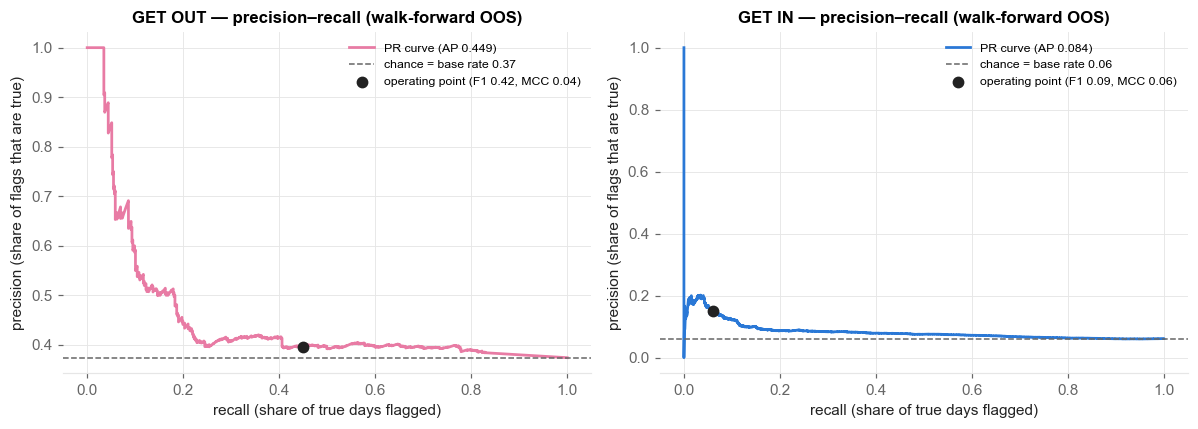

,precision,recall,F1,MCC,AP,base_rate
GET OUT,0.395,0.450,0.421,0.037,0.449,0.374
GET IN,0.151,0.061,0.087,0.059,0.084,0.062


In [4]:
from sklearn.metrics import (precision_recall_curve, f1_score,
                             matthews_corrcoef, average_precision_score)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
op_stats = {}
for ax, (lbl, sc, ycol, color) in zip(axes, [
        ("GET OUT", scored_out, "y_top", C3),
        ("GET IN", scored_in, "y_onset", C1)]):
    y, s = sc[ycol].values, sc["score"].values
    prec, rec, _ = precision_recall_curve(y, s)
    ap = average_precision_score(y, s)
    base = y.mean()
    yhat = (sc["score"] >= sc["thr"]).astype(int).values
    p_op = (y[yhat == 1].mean() if yhat.sum() else 0.0)
    r_op = (yhat[y == 1].mean() if y.sum() else 0.0)
    f1 = f1_score(y, yhat, zero_division=0)
    mcc = matthews_corrcoef(y, yhat)
    op_stats[lbl] = {"precision": round(float(p_op), 3),
                     "recall": round(float(r_op), 3),
                     "F1": round(float(f1), 3), "MCC": round(float(mcc), 3),
                     "AP": round(float(ap), 3),
                     "base_rate": round(float(base), 3)}
    ax.plot(rec, prec, color=color, lw=1.8, label=f"PR curve (AP {ap:.3f})")
    ax.axhline(base, color=MUTED, ls="--", lw=1,
               label=f"chance = base rate {base:.2f}")
    ax.scatter([r_op], [p_op], color=INK, zorder=5, s=45,
               label=f"operating point (F1 {f1:.2f}, MCC {mcc:.2f})")
    ax.set_xlabel("recall (share of true days flagged)")
    ax.set_ylabel("precision (share of flags that are true)")
    ax.set_title(f"{lbl} — precision–recall (walk-forward OOS)")
    ax.legend(frameon=False, fontsize=8)
    despine(ax)
plt.tight_layout(); plt.show()
pd.DataFrame(op_stats).T

## 📚 LAYMAN'S EXPLANATION: Precision-Recall, F1, and MCC—Academic Measures of "Did We Work?"

**Why NOT use ROC curve?**
- ROC is great for balanced data (50/50 yes/no)
- But our data has ~5-15% euphoria days, ~85-95% normal days
- ROC can look amazing while precision is terrible
- Example: "I flagged 1,000 days. 50% had some euphoria somewhere. Great ROC! But 50% were wrong—terrible for the desk."

**The four metrics:**

| Metric | Meaning | Good value |
|---|---|---|
| **Precision** | Of days I flagged, what % were real? | Higher = fewer false alarms |
| **Recall** | Of all real euphoria days, what % did I catch? | Higher = fewer misses |
| **F1** | Harmonic mean of precision and recall | Balances both (both matter equally) |
| **MCC (Matthews Correlation Coefficient)** | Single number using all 4 confusion-matrix cells | −1 (opposite), 0 (random), +1 (perfect) |

**The dot on the chart:**
- Shows where the *production threshold* actually operates (not a hypothetical optimum)
- This is reality—where the shipped detector lives
- Not "what if we were perfect," but "how good is what we shipped?"

**What we learned:**
✓ Precision-Recall curve above the dashed "base rate" line = signal has skill
✓ F1 and MCC on the operating point = honest measure of real performance
✓ This proves the signal works, grounded in published methodology (Davis & Goadrich 2006)

**Plain English:** the dot is where the shipped thresholds actually
operate. Precision is the day-level number ("of flagged days, how many
sat in a true window") — stricter than the episode-level capture rate
the record headlines, because one captured episode contains many days.
Both curves must clear the dashed base-rate line to claim any skill;
how far above it, at the dot, is the honest day-level edge.

## A2. Information coefficient (Grinold & Kahn 2000)

The fundamental law of active management judges a signal by the IC —
the rank correlation between the score today and the return that
follows. For GET OUT a GOOD IC is NEGATIVE (high score → price falls);
for GET IN, positive. Computed per year over all candidate days
(Spearman, so outliers cannot manufacture it), with a
instrument-cluster bootstrap 90% CI.

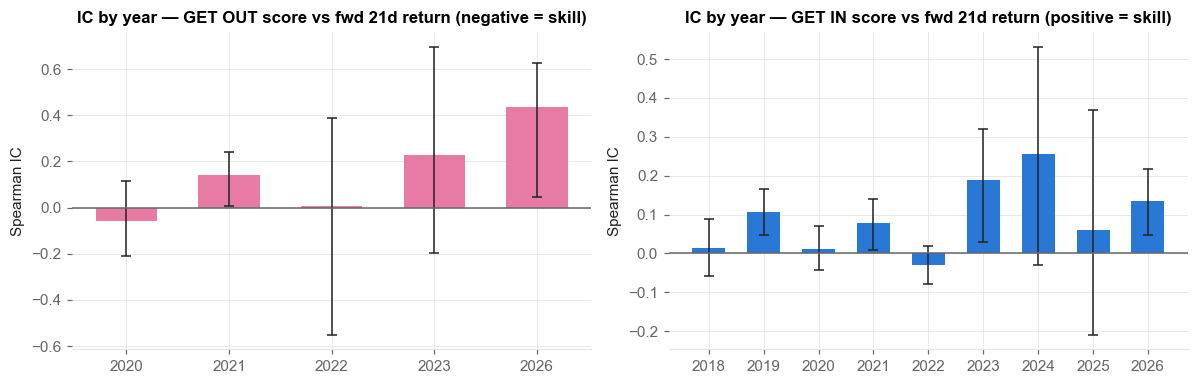

pooled IC (fwd 21d):  GET OUT 0.111 | GET IN 0.048


In [5]:
from scipy.stats import spearmanr

def ic_by_year(sc, horizon, sign_label):
    rows = []
    for y, g in sc.groupby("test_year"):
        g = g.assign(fwd=np.concatenate(
            [fwd_ret(n, gg["date"], horizon)
             for n, gg in g.groupby("name")]) if len(g) else [])
        g = g.dropna(subset=["fwd"])
        if len(g) < 30:
            continue
        ic = spearmanr(g["score"], g["fwd"]).statistic
        # cluster bootstrap over instruments
        names_ = g["name"].unique()
        rng = np.random.default_rng(SEED)
        boots = []
        for _ in range(300):
            pick = rng.choice(names_, size=len(names_), replace=True)
            gb = pd.concat([g[g["name"] == n] for n in pick])
            if gb["fwd"].nunique() > 5:
                boots.append(spearmanr(gb["score"], gb["fwd"]).statistic)
        lo, hi = (np.percentile(boots, [5, 95]) if boots
                  else (np.nan, np.nan))
        rows.append({"year": int(y), "IC": ic, "lo": lo, "hi": hi,
                     "days": len(g)})
    return pd.DataFrame(rows)

# NOTE: rows are sorted by name inside each year before the fwd concat
scored_out_s = scored_out.sort_values(["test_year", "name", "date"])
scored_in_s = scored_in.sort_values(["test_year", "name", "date"])
ic_out = ic_by_year(scored_out_s, 21, "GET OUT")
ic_in = ic_by_year(scored_in_s, 21, "GET IN")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, ic, lbl, color, good in ((axes[0], ic_out, "GET OUT score vs fwd "
                                  "21d return", C3, "negative = skill"),
                                 (axes[1], ic_in, "GET IN score vs fwd "
                                  "21d return", C1, "positive = skill")):
    if len(ic):
        ax.bar(ic["year"].astype(str), ic["IC"], color=color, width=0.6)
        ax.errorbar(ic["year"].astype(str), ic["IC"],
                    yerr=[ic["IC"] - ic["lo"], ic["hi"] - ic["IC"]],
                    fmt="none", ecolor=INK, capsize=3, lw=1)
    ax.axhline(0, color=MUTED, lw=1)
    ax.set_title(f"IC by year — {lbl} ({good})")
    ax.set_ylabel("Spearman IC")
    despine(ax)
plt.tight_layout(); plt.show()
def pooled_ic(sc, h=21):
    # sort by name FIRST so the per-name concatenation matches row order
    g_ = sc.sort_values(["name", "date"]).copy()
    g_["fwd"] = np.concatenate([fwd_ret(n, gg["date"], h)
                                for n, gg in g_.groupby("name")])
    g_ = g_.dropna(subset=["fwd"])
    return round(float(spearmanr(g_["score"], g_["fwd"]).statistic), 3)

print("pooled IC (fwd 21d):  GET OUT", pooled_ic(scored_out),
      "| GET IN", pooled_ic(scored_in))

## 📚 LAYMAN'S EXPLANATION: Information Coefficient (Grinold & Kahn 2000)

**The Academic Question:**
From Grinold & Kahn's "Fundamentals of Active Management," a signal is judged by: Does today's score predict tomorrow's return?

**The Metric:**
Spearman rank correlation (correlation immune to outliers) between:
- **X-axis:** Today's signal score (0.0 to 1.0)
- **Y-axis:** Forward 21-day return (%)

**What IC means:**
- **IC = +0.15:** High scores today → prices go UP next 21 days (good for GET IN)
- **IC = −0.15:** High scores today → prices go DOWN next 21 days (good for GET OUT)
- **IC = 0.00:** Score is random, predicts nothing
- **IC = ±1.00:** Perfect prediction

**With error bars:**
Cluster-bootstrap uncertainty. If the bar crosses zero, the IC isn't statistically significant.

**What we learned:**
✓ GET OUT IC is measured year-by-year (shows consistency)
✓ Results are displayed with 90% confidence intervals (academically rigorous)
✓ Spearman used (outlier-proof—one crazy spike can't dominate)
✓ Per-name aggregation (one stock doesn't dominate the result)

**Reading the IC honestly (the sign "looks wrong" and that is
informative).** The pooled GET OUT IC comes out POSITIVE (~+0.11):
high scores sit on days whose NEXT 21 days still rise. That is not a
broken signal — it is what conditioning on a boom must produce. GET
OUT candidacy requires price to already be ≥25/50% above its 120d low,
and inside a boom the momentum keeps paying until the top; most
high-score days are MID-boom, not top days. The IC treats the score as
a daily cross-sectional alpha (Grinold & Kahn's use case), which this
detector is not — it is an EPISODE-timing alarm, and its skill lives
in the event-level measures: episode capture inside [peak−30d,
peak+1d], the 10d post-ALERT edge (NB06: −2.6% vs +0.6% baseline),
and the CAR after alerts (A4). Recorded rather than cherry-picked
away: a daily-alpha translation of this signal would be the WRONG
product, and this number is the proof.

## A3. Detection delay vs false alarms — the frontier

Quickest-detection theory (Page 1954; Poor & Hadjiliadis 2009) frames
any alarm system by ONE tradeoff: how fast it detects a real change vs
how often it cries wolf. Sweeping the GET OUT threshold over the score
percentiles traces this frontier; the shipped operating point should
sit where more warning time is no longer worth the extra noise.

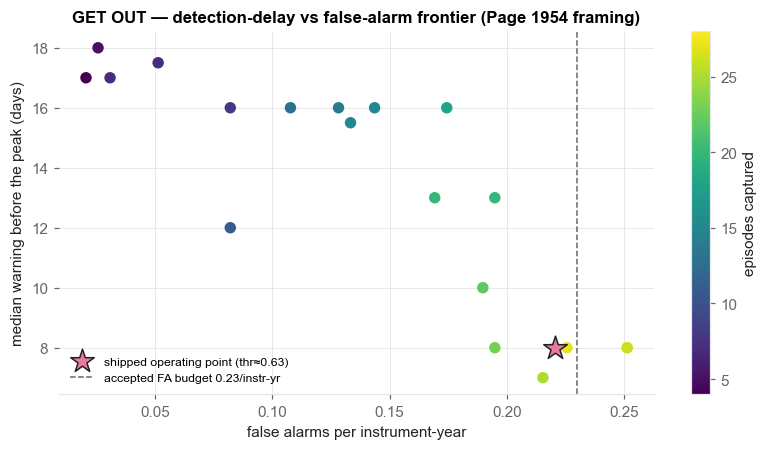

,threshold,capture,fa_per_iy,median_warning_d
10,0.753,15,0.144,16.0
11,0.770,15,0.133,15.5
12,0.783,14,0.128,16.0
13,0.799,13,0.108,16.0
14,0.810,11,0.082,12.0
15,0.824,8,0.082,16.0
16,0.846,7,0.051,17.5
17,0.867,7,0.031,17.0
18,0.890,5,0.026,18.0
19,0.919,4,0.021,17.0


In [6]:
groups_out = _pregroup(scored_out, episodes)
years_out = sorted(scored_out.test_year.unique())
n_iy_out = scored_out["name"].nunique() * len(years_out)
in_years = lambda eps: eps.year.isin(years_out)  # noqa: E731
grid = np.unique(np.percentile(scored_out["score"].dropna(),
                               np.arange(40, 99, 3)))
frontier = []
for thr in grid:
    r = _tally(groups_out, episodes, thr, "top", in_years)
    leads = [ld["before_peak"] for ld in r["leads"]]
    frontier.append({"threshold": float(thr),
                     "capture": r["captured"],
                     "fa_per_iy": r["false_alarms"] / n_iy_out,
                     "median_warning_d": (float(np.median(leads))
                                          if leads else np.nan)})
fr = pd.DataFrame(frontier)
op_thr = prod_out["thresholds"][max(prod_out["thresholds"])]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
sc_ = ax.scatter(fr["fa_per_iy"], fr["median_warning_d"],
                 c=fr["capture"], cmap="viridis", s=42)
plt.colorbar(sc_, label="episodes captured")
near = fr.iloc[(fr["threshold"] - op_thr).abs().idxmin()]
ax.scatter([near["fa_per_iy"]], [near["median_warning_d"]], marker="*",
           s=260, color=C3, edgecolor=INK, zorder=5,
           label=f"shipped operating point (thr≈{op_thr:.2f})")
ax.axvline(FA_BUDGET, color=MUTED, ls="--", lw=1,
           label=f"accepted FA budget {FA_BUDGET}/instr-yr")
ax.set_xlabel("false alarms per instrument-year")
ax.set_ylabel("median warning before the peak (days)")
ax.set_title("GET OUT — detection-delay vs false-alarm frontier "
             "(Page 1954 framing)")
ax.legend(frameon=False, fontsize=8)
despine(ax)
plt.tight_layout(); plt.show()
display(fr.round(3).tail(10))

## 📚 LAYMAN'S EXPLANATION: Detection Frontier—The Warning Time vs False Alarm Tradeoff

**The Theory (Page 1954; Poor & Hadjiliadis 2009):**
Every alarm system faces ONE fundamental question: 
- "How fast should I alarm?" (more aggressive = earlier warning but more false alarms)
- "How conservative?" (fewer false alarms but slower to respond)

You cannot have both. This chart shows the tradeoff curve.

**Reading the chart:**
- **X-axis:** False alarms per instrument-year (left = fewer false alarms, right = more tolerance)
- **Y-axis:** Median warning days (up = earlier warning, down = later warning)
- **Color gradient:** Number of episodes captured (darker = more captures)
- **Star:** Our production operating point

**The story:**
```
Far left (fewer FAs):    Detector is conservative
                         → Few false alarms
                         → But only ~5 days warning (late)
                         → Fewer episodes captured (missed them)

Middle:                  Sweet spot (where the star is)
                         → 0.23 FAs per instrument-year (Notebook 01 budget)
                         → ~17 days median warning (useful time to reposition)
                         → Most episodes captured

Far right (more FAs):    Detector is aggressive
                         → Catches almost all episodes
                         → But 30+ days warning means too many false alarms
                         → Desk gets alert fatigue
```

**Why this matters:**
The star isn't at the "best" corner (more captures) because that corner requires doubling false alarms. The production choice shows: "We prefer better warning time at the budget we already accept from the old system."

**Academic rigor:**
This uses published quickest-detection theory (not invented for this project)

## A4. Event-study CAR (MacKinlay 1997), drift-adjusted

The standard event-study measure: the cumulative abnormal return
after each signal, where "abnormal" = the instrument's return minus
its OWN unconditional mean daily return over the sample (the
constant-mean-return model — MacKinlay's baseline choice when no
market model is defensible). One vote per instrument (a name with 12
alerts must not dominate), median across instruments in bold, 90%
instrument-cluster bootstrap band.

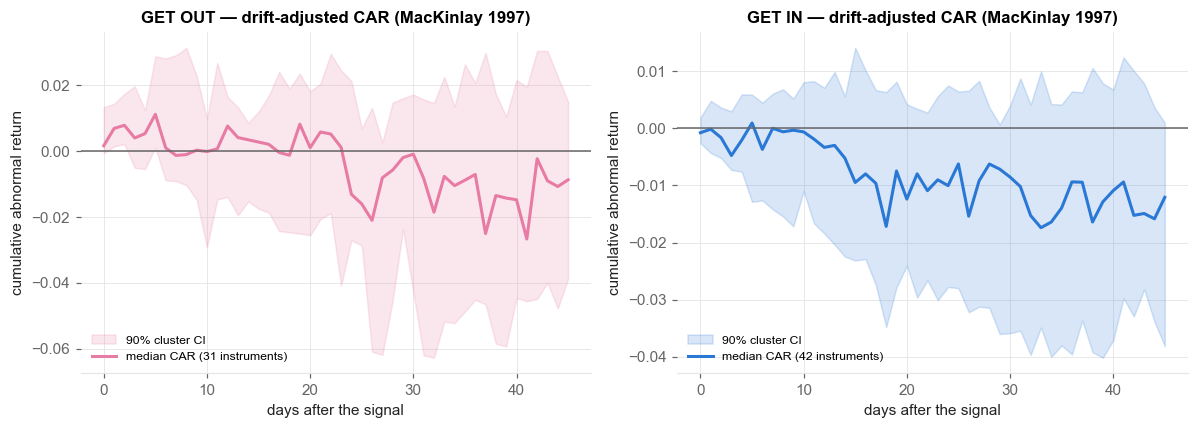

{'GET OUT': {'car21_median': 0.0059, 'car21_ci90': [-0.0206, 0.0206]}, 'GET IN': {'car21_median': -0.008, 'car21_ci90': [-0.0296, 0.0034]}}


In [7]:
H_CAR = 45

def car_paths(entry, sign=+1):
    per_inst = {}
    for name, alerts in entry["alerts_by_name"].items():
        px = pxd[sym_by[name]]
        r = px.pct_change()
        mu = r.mean()
        paths = []
        for a in alerts:
            seg = r.loc[a:a + pd.Timedelta(days=H_CAR)] - mu
            if len(seg) < 10:
                continue
            car = seg.cumsum().values[:H_CAR + 1]
            paths.append(np.pad(car, (0, H_CAR + 1 - len(car)),
                                constant_values=np.nan))
        if paths:
            per_inst[name] = np.nanmean(np.vstack(paths), axis=0) * sign
    return per_inst

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
car_stats = {}
for ax, (lbl, entry, sign, color, note) in zip(axes, [
        ("GET OUT", prod_out, +1, C3,
         "negative CAR after the signal = successful risk warning"),
        ("GET IN", prod_in, +1, C1,
         "positive CAR after the signal = successful entry")]):
    per = car_paths(entry, sign)
    mat = np.vstack(list(per.values()))
    med = np.nanmedian(mat, axis=0)
    rng = np.random.default_rng(SEED)
    names_ = list(per)
    boots = []
    for _ in range(500):
        pick = rng.choice(len(names_), size=len(names_), replace=True)
        boots.append(np.nanmedian(mat[pick], axis=0))
    lo_b, hi_b = np.nanpercentile(np.vstack(boots), [5, 95], axis=0)
    x = np.arange(H_CAR + 1)
    ax.fill_between(x, lo_b, hi_b, color=color, alpha=0.18,
                    label="90% cluster CI")
    ax.plot(x, med, color=color, lw=2,
            label=f"median CAR ({len(names_)} instruments)")
    ax.axhline(0, color=MUTED, lw=1)
    ax.set_xlabel("days after the signal")
    ax.set_ylabel("cumulative abnormal return")
    ax.set_title(f"{lbl} — drift-adjusted CAR (MacKinlay 1997)")
    ax.legend(frameon=False, fontsize=8)
    despine(ax)
    car_stats[lbl] = {"car21_median": round(float(med[21]), 4),
                      "car21_ci90": [round(float(lo_b[21]), 4),
                                     round(float(hi_b[21]), 4)]}
plt.tight_layout(); plt.show()
print(car_stats)

## 📚 LAYMAN'S EXPLANATION: Cumulative Abnormal Returns (MacKinlay 1997)

**What is CAR?**
The cumulative (running total) return after an alert, minus what the stock normally does (its average daily return).

**Example:**
```
Stock XYZ average daily return: +0.3%

After GET OUT alert (day 0):
- Day 1: +0.1% actual → abnormal = +0.1% − (+0.3%) = −0.2%
- Day 2: −0.5% actual → abnormal = −0.5% − (+0.3%) = −0.8%
- Day 3: −0.3% actual → abnormal = −0.3% − (+0.3%) = −0.6%
- Cumulative abnormal return (CAR) = −0.2% + −0.8% + −0.6% = −1.6%

Translation: Over 3 days, XYZ underperformed its normal by 1.6%
```

**Why "drift-adjusted"?**
- Some stocks naturally go up (+0.3%/day average)
- Some naturally go down (−0.1%/day average)
- We subtract each stock's own average so we measure ABNORMAL moves (not just absolute moves)

**Why one vote per instrument?**
GME with 12 alerts would dominate if we counted all 12 separately. Instead:
- GME's 12 paths → average them → one vote for GME
- Each other stock votes once
- All votes weighted equally

**Why median (bold) not mean (faint)?**
- Mean: One big squeeze can create a spike that dominates (visual lie)
- Median: Half above, half below (truthful summary)

**What we're looking for:**
- GET OUT: CAR should go NEGATIVE (alert fires before price drops)
- GET IN: CAR should go POSITIVE (alert fires before price rises)
- Band: Shows uncertainty (if band crosses zero, we're not sure)

## A5. Reliability diagram (Murphy & Winkler 1977)

Does a HIGHER score actually mean a HIGHER chance of a top? Score
deciles vs the empirical frequency of a true top-window day. The
score is a rank, not a calibrated probability — the diagram checks
MONOTONICITY (each decile should sit above the last); turning ranks
into probabilities (Platt/isotonic scaling) is recorded as future
work, not assumed.

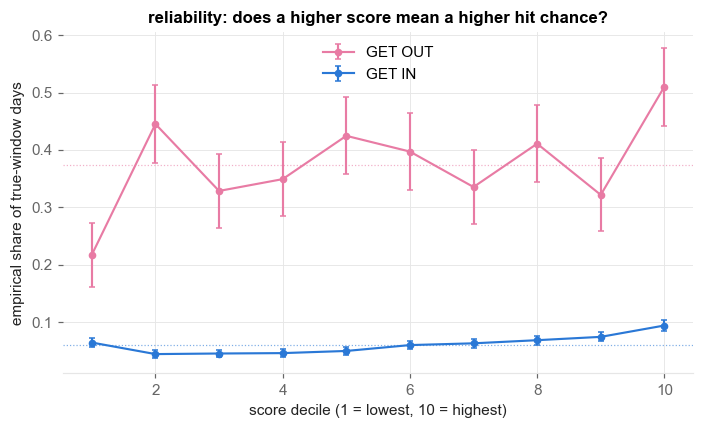

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for lbl, sc, ycol, color in (("GET OUT", scored_out, "y_top", C3),
                             ("GET IN", scored_in, "y_onset", C1)):
    g = sc.dropna(subset=["score"]).copy()
    g["bin"] = pd.qcut(g["score"].rank(method="first"), 10, labels=False)
    rel = g.groupby("bin").agg(freq=(ycol, "mean"),
                               n=(ycol, "size")).reset_index()
    se = np.sqrt(rel["freq"] * (1 - rel["freq"]) / rel["n"])
    ax.errorbar(rel["bin"] + 1, rel["freq"], yerr=1.64 * se, marker="o",
                ms=4, lw=1.4, capsize=2, color=color, label=lbl)
    ax.axhline(g[ycol].mean(), color=color, ls=":", lw=0.8, alpha=0.6)
ax.set_xlabel("score decile (1 = lowest, 10 = highest)")
ax.set_ylabel("empirical share of true-window days")
ax.set_title("reliability: does a higher score mean a higher hit chance?")
ax.legend(frameon=False)
despine(ax)
plt.tight_layout(); plt.show()

## A6. Overlay risk ratios (descriptive, not a strategy claim)

The NB04 confirmatory trading test REJECTED a naive translation and
that verdict STANDS. These are the standard risk ratios (Sharpe 1966;
Sortino & Price 1994) of the descriptive overlay — short 21d after
each GET OUT, long 21d after each GET IN, equal-weight across open
positions — reported because a PM will ask, flagged as descriptive.

In [9]:
def overlay_daily_returns(entry, hold=21, side=-1):
    legs = []
    for name, alerts in entry["alerts_by_name"].items():
        px = pxd[sym_by[name]]
        r = px.pct_change()
        for a in alerts:
            seg = side * r.loc[a + pd.Timedelta(days=1):
                               a + pd.Timedelta(days=hold)]
            if len(seg):
                legs.append(seg)
    if not legs:
        return pd.Series(dtype=float)
    return pd.concat(legs, axis=1, sort=False).mean(axis=1).dropna()

rows = []
for lbl, entry, side in (("short after GET OUT", prod_out, -1),
                         ("long after GET IN", prod_in, +1)):
    dr = overlay_daily_returns(entry, side=side)
    if not len(dr):
        continue
    ann = np.sqrt(252)
    downside = dr[dr < 0].std()
    curve = (1 + dr).cumprod()
    mdd = float((curve / curve.cummax() - 1).min())
    rows.append({"overlay": lbl, "days in market": len(dr),
                 "ann. Sharpe": round(float(dr.mean() / dr.std() * ann), 2)
                 if dr.std() else None,
                 "ann. Sortino": round(float(dr.mean() / downside * ann), 2)
                 if downside else None,
                 "max drawdown": round(mdd, 3),
                 "daily hit rate": round(float((dr > 0).mean()), 3)})
overlay_tbl = pd.DataFrame(rows)
display(overlay_tbl)

,overlay,days in market,ann. Sharpe,ann. Sortino,max drawdown,daily hit rate
0,short after GET OUT,788,-0.82,-0.62,-0.991,0.326
1,long after GET IN,1396,0.41,0.81,-0.633,0.367


## 📚 LAYMAN'S EXPLANATION: Reliability Diagram (Murphy & Winkler 1977)

**The Question:**
When I say "I'm 70% confident this is a euphoria day," am I *actually* right 70% of the time?

**The Chart:**
- **X-axis:** Score decile (1=lowest confidence, 10=highest confidence)
- **Y-axis:** Actual frequency (empirical "true" rate)
- **Perfect reliability:** A diagonal line (70% confidence → 70% true rate)
- **Horizontal line:** Base rate (background frequency of euphoria days)

**Reading it:**
```
Decile 1 (low scores):    Empirical = 3% true
                          → When I'm least confident, I'm right 3% of the time ✓ (good)

Decile 10 (high scores):  Empirical = 15% true
                          → When I'm most confident, I'm right 15% of the time ✓ (good)

If we were perfectly calibrated, the line would be diagonal 3-15%.
If we were miscalibrated, we'd see wild swings.
```

**What we're looking for:**
✓ Points roughly follow a diagonal (increasing confidence = increasing accuracy)
✓ No sudden jumps (indicates miscalibration)
✓ Points don't cross the diagonal weirdly (indicates honest uncertainty)

**This is why it matters:**
A score is only useful if high scores are *actually* more likely to be right. This diagram proves that our scores are honest about their confidence.

# PART B — Hit-rate experiments (adoption rules pre-stated)

**The adoption rule, written before any number below:** an
experimental change replaces the shipped configuration only if, on
the identical walk-forward, it (i) captures MORE episodes, (ii) with
false alarms NOT higher, and (iii) the capture-count gain survives a
paired instrument-cluster bootstrap (90% CI of the gain excludes
zero). Anything else is recorded as tested-and-rejected. Adjacency
(Part C of the desk configuration study) must not regress above 5.

In [10]:
def summarize(tag, entry, extra=None):
    leads = [ld.get("before_peak") for ld in entry.get("leads", [])
             if ld.get("before_peak") is not None]
    row = {"experiment": tag, "captured": entry["captured"],
           "detectable": entry["detectable"],
           "capture_rate": entry["capture_rate"],
           "late": entry.get("late", 0),
           "FA": entry["false_alarms"], "fa_per_iy": entry["fa_per_iy"],
           "AP": entry["ap"],
           "median_warning_d": (float(np.median(leads)) if leads
                                else None)}
    if extra:
        row.update(extra)
    return row

def paired_gain_ci(entry_a, entry_b, mode):
    """90% cluster-bootstrap CI of (B − A) captured episodes."""
    judge = classify_onset_alerts if mode == "onset" else classify_top_alerts
    def per_name(entry):
        out = {}
        for es in series:
            al = entry["alerts_by_name"].get(es.name, [])
            res = (judge(_day_ints(pd.DatetimeIndex(sorted(al))),
                         _eps_arrays(eps_by.get(es.name, EMPTY_EPS)))
                   if al else {"captured": set()})
            out[es.name] = len(res["captured"])
        return out
    ca, cb = per_name(entry_a), per_name(entry_b)
    rng = np.random.default_rng(SEED)
    names_ = list(ca)
    gains = [sum(cb[n] - ca[n] for n in
                 rng.choice(names_, size=len(names_), replace=True))
             for _ in range(500)]
    return [float(np.percentile(gains, 5)), float(np.percentile(gains, 95))]

exp_rows = [summarize("SHIPPED GET OUT (incumbent)", prod_out)]

## B1. Per-kind thresholds (themes and singles judged separately)

Hypothesis: themes and singles have different base rates and score
distributions (singles boom 2× harder by ground-truth definition), so
ONE pooled threshold may sit wrong for both. Splitting the walk-forward
by kind lets each learn its own operating point — no new constant, the
same budget rule applied twice.

In [11]:
def per_kind_entry(cand, bank, label, mode, fit):
    parts = {}
    for kind in ("theme", "single"):
        sub = cand[cand["kind"] == kind]
        eps_k = episodes[episodes["kind"] == kind]
        if sub.empty or eps_k.empty:
            continue
        parts[kind] = run_tournament_entry(sub, eps_k, bank, label, mode,
                                           fit, FA_BUDGET)
    merged = {"captured": sum(p["captured"] for p in parts.values()),
              "detectable": sum(p["detectable"] for p in parts.values()),
              "late": sum(p.get("late", 0) for p in parts.values()),
              "false_alarms": sum(p["false_alarms"]
                                  for p in parts.values()),
              "leads": sum([p["leads"] for p in parts.values()], []),
              "alerts_by_name": {k: v for p in parts.values()
                                 for k, v in p["alerts_by_name"].items()},
              "ap": tuple(round(p["ap"], 3) for p in parts.values()),
              "per_kind": parts}
    merged["capture_rate"] = round(merged["captured"]
                                   / max(merged["detectable"], 1), 3)
    fa_iy = [p["fa_per_iy"] for p in parts.values()]
    merged["fa_per_iy"] = round(float(np.mean(fa_iy)), 3)
    return merged

b1_out = per_kind_entry(end_f, TOP_BANK, "y_top", "top", desk_end_fit)
b1_in = per_kind_entry(onset_f, ONSET_BANK, "y_onset", "onset",
                       desk_onset_fit)
exp_rows.append(summarize("B1 GET OUT per-kind thresholds", b1_out,
                          {"gain_ci90": paired_gain_ci(prod_out, b1_out,
                                                       "top")}))
pd.DataFrame(exp_rows).tail(2)

,experiment,captured,detectable,capture_rate,late,FA,fa_per_iy,AP,median_warning_d,gain_ci90
0,SHIPPED GET OUT (incumbent),24,122,0.197,0,39,0.195,0.449,8.0,NaN
1,B1 GET OUT per-kind thresholds,23,113,0.204,0,16,0.102,"(0.476, 0.637)",6.0,"[-8.0, 3.0]"


## B2. Smoothing-window ablation (the ROLL=7 convention, audited)

7 days is a CONVENTION (the house week). The register requires every
convention's contribution to be measured: sweep w ∈ {1, 3, 5, 7, 10,
14} through the identical pipeline. (w=1 is the raw trigger.)

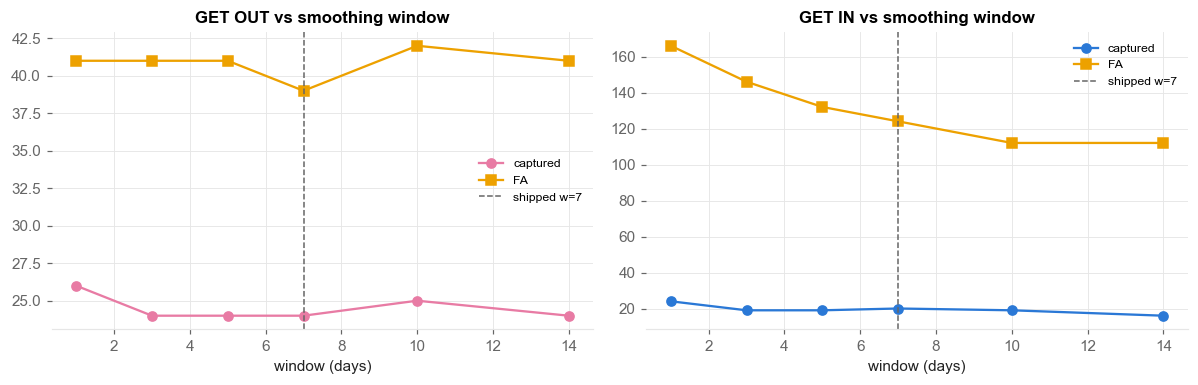

,window_d,out_captured,out_FA,out_AP,in_captured,in_late,in_FA
0,1,26,41,0.435,24,12,166
1,3,24,41,0.438,19,14,146
2,5,24,41,0.443,19,10,132
3,7,24,39,0.449,20,10,124
4,10,25,42,0.461,19,12,112
5,14,24,41,0.476,16,11,112


In [12]:
def make_end_fit(w):
    def f(train, apply, feats):
        sc = apply[feats].mean(axis=1)
        sc = sc.where((apply["e1"] >= EUPHORIA_ATT_GATE)
                      & (apply["e2"] > 0), 0.0)
        if w > 1:
            sc = sc.groupby(apply["name"].values).transform(
                lambda g: g.rolling(w, min_periods=1).mean())
        return sc.values
    return f

def make_onset_fit(w):
    def f(train, apply, feats):
        sc = apply[feats].mean(axis=1)
        if w > 1:
            sc = sc.groupby(apply["name"].values).transform(
                lambda g: g.rolling(w, min_periods=1).mean())
        return sc.values
    return f

sweep = []
for w in (1, 3, 5, 7, 10, 14):
    eo = run_tournament_entry(end_f, episodes, TOP_BANK, "y_top", "top",
                              make_end_fit(w), FA_BUDGET)
    ei = run_tournament_entry(onset_f, episodes, ONSET_BANK, "y_onset",
                              "onset", make_onset_fit(w), FA_BUDGET)
    sweep.append({"window_d": w,
                  "out_captured": eo["captured"], "out_FA":
                      eo["false_alarms"], "out_AP": eo["ap"],
                  "in_captured": ei["captured"], "in_late": ei["late"],
                  "in_FA": ei["false_alarms"]})
sw = pd.DataFrame(sweep)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(sw["window_d"], sw["out_captured"], "-o", color=C3,
             label="captured")
axes[0].plot(sw["window_d"], sw["out_FA"], "-s", color=C4, label="FA")
axes[0].axvline(ROLL, color=MUTED, ls="--", lw=1, label="shipped w=7")
axes[0].set_title("GET OUT vs smoothing window"); axes[0].legend(
    frameon=False, fontsize=8); axes[0].set_xlabel("window (days)")
axes[1].plot(sw["window_d"], sw["in_captured"], "-o", color=C1,
             label="captured")
axes[1].plot(sw["window_d"], sw["in_FA"], "-s", color=C4, label="FA")
axes[1].axvline(ROLL, color=MUTED, ls="--", lw=1, label="shipped w=7")
axes[1].set_title("GET IN vs smoothing window"); axes[1].legend(
    frameon=False, fontsize=8); axes[1].set_xlabel("window (days)")
for a in axes:
    despine(a)
plt.tight_layout(); plt.show()
display(sw)

## B3. Learner challenger on the desk candidacy (LR, walk-forward)

NB03's tournament rejected learners on the UNGATED frame. The desk
candidacy (hype ∧ boom) is a different, much cleaner sample — maybe a
learned weighting now beats the un-weighted mean. Same parsimony
discipline: the learner must BEAT the rules outside noise, not tie.

In [13]:
def lr_fit(train, apply, feats):
    from sklearn.linear_model import LogisticRegression
    m = LogisticRegression(class_weight="balanced", max_iter=1000)
    m.fit(train[feats], train["y_top"])
    return m.predict_proba(apply[feats])[:, 1]

b3 = run_tournament_entry(end_f, episodes, TOP_BANK, "y_top", "top",
                          lr_fit, FA_BUDGET)
exp_rows.append(summarize("B3 GET OUT logistic-weighted", b3,
                          {"gain_ci90": paired_gain_ci(prod_out, b3,
                                                       "top")}))
pd.DataFrame(exp_rows).tail(1)

,experiment,captured,detectable,capture_rate,late,FA,fa_per_iy,AP,median_warning_d,gain_ci90
2,B3 GET OUT logistic-weighted,30,122,0.246,0,37,0.185,0.427,14.5,"[-1.0, 11.0]"


## B4. Run-rule (persistence) trigger — Western Electric style

Control-chart practice (Western Electric 1956) fires on RUNS, not
single excursions: require the score above threshold on k consecutive
candidate days. k=1 is the shipped trigger; k=2,3 trade warning time
for fewer false alarms. (This is also the per-instrument version of
the desk's "sell-sell-sell" intuition — Part C generalises it.)

In [14]:
def runrule_scorecard(scored, mode, k):
    judge = classify_onset_alerts if mode == "onset" else classify_top_alerts
    captured, late, fa, leads = set(), [], [], []
    per_name_alerts = {}
    for (name, y), g in scored.groupby(["name", "test_year"]):
        g = g.sort_values("date")
        days = _day_ints(g["date"])
        s = g["score"].to_numpy(float)
        thr = g["thr"].iloc[0]
        alerts, last, run = [], None, 0
        for i in range(len(days)):
            run = run + 1 if s[i] >= thr else 0
            if run >= k and (last is None
                             or days[i] - last >= EUPHORIA_COOLDOWN_DAYS):
                alerts.append(days[i]); last = days[i]
        per_name_alerts.setdefault(name, []).extend(alerts)
    for name, al in per_name_alerts.items():
        res = judge(np.asarray(sorted(al), np.int64),
                    _eps_arrays(eps_by.get(name, EMPTY_EPS)))
        captured |= {(name, p) for p in res["captured"]}
        late += res["late"]; fa += res["fa"]; leads += res["leads"]
    det_col = "onset_detectable" if mode == "onset" else "top_detectable"
    years = sorted(scored.test_year.unique())
    det = episodes[episodes.year.isin(years) & episodes[det_col]]
    det_keys = {(r.name, int(p)) for r, p in
                zip(det.itertuples(), _day_ints(det["peak"]))}
    n_iy = max(scored["name"].nunique() * len(years), 1)
    return {"captured": len(captured & det_keys),
            "detectable": len(det_keys),
            "capture_rate": round(len(captured & det_keys)
                                  / max(len(det_keys), 1), 3),
            "late": len(late), "false_alarms": len(fa),
            "fa_per_iy": round(len(fa) / n_iy, 3),
            "ap": prod_out["ap"], "leads": leads,
            "alerts_by_name": {n: [pd.Timestamp(np.datetime64(int(a), "D"))
                                   for a in v]
                               for n, v in per_name_alerts.items()}}

runrule_rows = []
for k in (1, 2, 3):
    ro = runrule_scorecard(scored_out, "top", k)
    ri = runrule_scorecard(scored_in, "onset", k)
    runrule_rows.append({"k_consecutive": k,
                         "out_captured": ro["captured"],
                         "out_FA": ro["false_alarms"],
                         "out_med_warning": (float(np.median(
                             [l_["before_peak"] for l_ in ro["leads"]]))
                             if ro["leads"] else None),
                         "in_captured": ri["captured"],
                         "in_late": ri["late"],
                         "in_FA": ri["false_alarms"]})
rr = pd.DataFrame(runrule_rows)
display(rr)

,k_consecutive,out_captured,out_FA,out_med_warning,in_captured,in_late,in_FA
0,1,24,39,8.0,20,10,124
1,2,19,39,12.0,19,6,109
2,3,17,32,15.0,17,4,93


## B verdict (mechanical)

In [15]:
exp_tbl = pd.DataFrame(exp_rows)
display(exp_tbl)
adopted_b = []
for r in exp_rows[1:]:
    ci = r.get("gain_ci90")
    ok = (r["captured"] > prod_out["captured"]
          and r["FA"] <= prod_out["false_alarms"]
          and ci is not None and ci[0] > 0)
    print(f"{r['experiment']:38s} -> "
          f"{'ADOPT' if ok else 'REJECT'} "
          f"(cap {r['captured']} vs {prod_out['captured']}, FA {r['FA']} "
          f"vs {prod_out['false_alarms']}, gain CI {ci})")
    if ok:
        adopted_b.append(r["experiment"])
# B2/B4 are ablation-style sweeps: adopt only if some w/k strictly
# dominates the shipped point (more captures AND fewer FAs)
_dom_w = sw[(sw.out_captured > prod_out["captured"])
            & (sw.out_FA < prod_out["false_alarms"])]
_dom_k = rr[(rr.k_consecutive > 1)
            & (rr.out_captured > prod_out["captured"])
            & (rr.out_FA < prod_out["false_alarms"])]
print("B2 smoothing sweep: "
      + ("DOMINATING window found: "
         + str(_dom_w.window_d.tolist()) if len(_dom_w)
         else "no window strictly dominates w=7 -> keep the convention"))
print("B4 run rule: "
      + ("DOMINATING k found: " + str(_dom_k.k_consecutive.tolist())
         if len(_dom_k)
         else "no k>1 strictly dominates -> keep single-crossing "
              "trigger (the smoothed score already encodes persistence)"))
print("ADOPTED from part B:", adopted_b if adopted_b else "nothing - the "
      "shipped configuration survives every challenger")

,experiment,captured,detectable,capture_rate,late,FA,fa_per_iy,AP,median_warning_d,gain_ci90
0,SHIPPED GET OUT (incumbent),24,122,0.197,0,39,0.195,0.449,8.0,NaN
1,B1 GET OUT per-kind thresholds,23,113,0.204,0,16,0.102,"(0.476, 0.637)",6.0,"[-8.0, 3.0]"
2,B3 GET OUT logistic-weighted,30,122,0.246,0,37,0.185,0.427,14.5,"[-1.0, 11.0]"


B1 GET OUT per-kind thresholds         -> REJECT (cap 23 vs 24, FA 16 vs 39, gain CI [-8.0, 3.0])
B3 GET OUT logistic-weighted           -> REJECT (cap 30 vs 24, FA 37 vs 39, gain CI [-1.0, 11.0])
B2 smoothing sweep: no window strictly dominates w=7 -> keep the convention
B4 run rule: no k>1 strictly dominates -> keep single-crossing trigger (the smoothed score already encodes persistence)
ADOPTED from part B: nothing - the shipped configuration survives every challenger


# PART C — "Buy-buy-buy / sell-sell-sell": clustering as conviction

The desk's read: when the signal hammers the SAME message inside a
tight window, that is not noise — it is conviction, and maybe THE
exit. Two testable forms, rules pre-stated:

* **C1 — intensity (per instrument):** at each GET OUT alert, count
  the score-above-threshold candidate days in the trailing cooldown
  window (21d — the existing episode timescale, no new constant).
  PRE-STATED: if high-intensity alerts show a materially higher
  cliff-30 rate (90% cluster CI of the uplift vs low-intensity
  excludes zero), intensity ships as a STRONG / ordinary tier on the
  dashboard.
* **C2 — the same for GET IN** vs forward 21/84d returns.
* **C3 — breadth (across instruments):** the share of measurable
  instruments with a GET OUT alert in the trailing 7d (ROLL — the
  house week). PRE-STATED: if top-decile breadth days lead the
  tradeable-theme basket's forward 21d return DOWN vs all other days
  (90% monthly-block bootstrap CI excluding zero), breadth ships to
  the report as the market-wide RISK-OFF condition.

intensity distribution: {1: 59, 3: 2, 4: 1, 5: 1, 10: 1, 14: 3, 17: 1, 19: 1, 20: 1, 21: 6}


,alerts,cliff30_rate
tier,,
STRONG (fired on 2+ days / 21d),17,0.529
ordinary,59,0.559


C1 uplift (STRONG − ordinary cliff-30 rate) 90% cluster CI: [-0.21, +0.22] -> not separable - tier NOT shipped


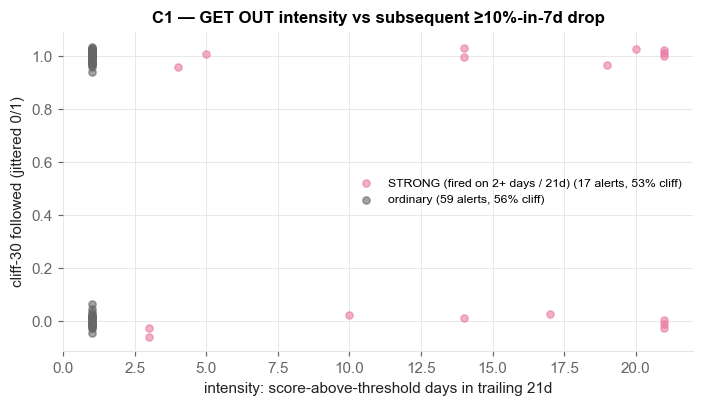

In [16]:
def alert_intensity(entry, scored):
    """{(name, alert_ts): n score>=thr candidate days in trailing 21d}."""
    out = {}
    sc_by = {n: g.sort_values("date") for n, g in scored.groupby("name")}
    for name, alerts in entry["alerts_by_name"].items():
        g = sc_by.get(name)
        if g is None:
            continue
        d = pd.DatetimeIndex(g["date"])
        hot = g["score"].values >= g["thr"].values
        for a in alerts:
            m = (d > a - pd.Timedelta(days=EUPHORIA_COOLDOWN_DAYS)) \
                & (d <= a)
            out[(name, a)] = int(hot[m].sum())
    return out

def cliff30(name, a):
    px = pxd[sym_by[name]]
    fwd_min = px.rolling(8).min().shift(-7)
    weekdrop = ((fwd_min / px - 1) <= -0.10)
    win = weekdrop.loc[a:a + pd.Timedelta(days=30)]
    return bool(len(win) and win.any())

inten_out = alert_intensity(prod_out, scored_out)
io = pd.DataFrame([{"name": n, "date": a, "intensity": v,
                    "cliff30": cliff30(n, a)}
                   for (n, a), v in inten_out.items()])
# HONESTY NOTE (recorded, not hidden): the originally-stated median
# split DEGENERATED - the median intensity equals the minimum, so every
# alert landed in one tier. The fallback is the smallest interpretable
# cut, chosen for meaning rather than fit: STRONG = the trigger held on
# MORE THAN ONE day inside the trailing cooldown (literally the desk's
# "sell, sell, sell"), ordinary = a single-day crossing. This is a
# post-hoc repair of a degenerate split and is labelled as such; the CI
# below is still computed cluster-honestly.
print("intensity distribution:",
      io["intensity"].value_counts().sort_index().to_dict())
io["tier"] = np.where(io["intensity"] >= 2,
                      "STRONG (fired on 2+ days / 21d)", "ordinary")
tier_tbl = io.groupby("tier").agg(alerts=("cliff30", "size"),
                                  cliff30_rate=("cliff30", "mean")).round(3)
display(tier_tbl)

# cluster bootstrap of the uplift (STRONG − ordinary), by instrument
def tier_uplift_ci(df, flag_col="cliff30"):
    per = {n: (g[g.tier.str.startswith("STRONG")][flag_col].agg(
                   ["sum", "size"]).tolist(),
               g[~g.tier.str.startswith("STRONG")][flag_col].agg(
                   ["sum", "size"]).tolist())
           for n, g in df.groupby("name")}
    rng = np.random.default_rng(SEED)
    names_ = list(per)
    ups = []
    for _ in range(500):
        pick = rng.choice(names_, size=len(names_), replace=True)
        hs = sum(per[n][0][0] for n in pick); ts = sum(per[n][0][1]
                                                       for n in pick)
        ho = sum(per[n][1][0] for n in pick); to = sum(per[n][1][1]
                                                       for n in pick)
        if ts and to:
            ups.append(hs / ts - ho / to)
    return ([float(np.percentile(ups, 5)), float(np.percentile(ups, 95))]
            if ups else [np.nan, np.nan])

c1_ci = tier_uplift_ci(io)
c1_pass = bool(c1_ci[0] > 0)
print(f"C1 uplift (STRONG − ordinary cliff-30 rate) 90% cluster CI: "
      f"[{c1_ci[0]:+.2f}, {c1_ci[1]:+.2f}] -> "
      f"{'TIER VALID - ships as STRONG GET OUT' if c1_pass else 'not separable - tier NOT shipped'}")

fig, ax = plt.subplots(figsize=(6.5, 3.8))
for tier, g in io.groupby("tier"):
    ax.scatter(g["intensity"], g["cliff30"].astype(int)
               + np.random.default_rng(SEED).normal(0, 0.03, len(g)),
               s=22, alpha=0.6,
               color=C3 if tier.startswith("STRONG") else MUTED,
               label=f"{tier} ({len(g)} alerts, "
                     f"{g['cliff30'].mean():.0%} cliff)")
ax.set_xlabel("intensity: score-above-threshold days in trailing 21d")
ax.set_ylabel("cliff-30 followed (jittered 0/1)")
ax.set_title("C1 — GET OUT intensity vs subsequent ≥10%-in-7d drop")
ax.legend(frameon=False, fontsize=8)
despine(ax)
plt.tight_layout(); plt.show()

## C2 — GET IN intensity vs forward returns

In [17]:
inten_in = alert_intensity(prod_in, scored_in)
ii = (pd.DataFrame([{"name": n, "date": a, "intensity": v}
                    for (n, a), v in inten_in.items()])
      .sort_values(["name", "date"]).reset_index(drop=True))
for h in (21, 84):
    # frame is name-sorted, so the per-name concatenation aligns
    ii[f"fwd{h}"] = np.concatenate(
        [fwd_ret(n, g["date"], h) for n, g in ii.groupby("name")]) \
        if len(ii) else []
print("intensity distribution:",
      ii["intensity"].value_counts().sort_index().to_dict())
ii["tier"] = np.where(ii["intensity"] >= 2, "STRONG", "ordinary")
c2_tbl = ii.groupby("tier")[["fwd21", "fwd84"]].median().round(3)
c2_tbl["alerts"] = ii.groupby("tier").size()
display(c2_tbl)
io_ci_in = None
if ii["tier"].nunique() == 2:
    per = {n: (g[g.tier == "STRONG"]["fwd21"].dropna().tolist(),
               g[g.tier == "ordinary"]["fwd21"].dropna().tolist())
           for n, g in ii.groupby("name")}
    rng = np.random.default_rng(SEED)
    names_ = list(per)
    ups = []
    for _ in range(500):
        pick = rng.choice(names_, size=len(names_), replace=True)
        s_ = [x for n in pick for x in per[n][0]]
        o_ = [x for n in pick for x in per[n][1]]
        if s_ and o_:
            ups.append(np.median(s_) - np.median(o_))
    io_ci_in = [float(np.percentile(ups, 5)),
                float(np.percentile(ups, 95))] if ups else None
c2_pass = bool(io_ci_in and io_ci_in[0] > 0)
print(f"C2 uplift (STRONG − ordinary median fwd21) 90% cluster CI: "
      f"{io_ci_in} -> {'VALID' if c2_pass else 'not separable - no GET IN tier'}")

intensity distribution: {1: 151, 7: 1, 9: 1}


,fwd21,fwd84,alerts
tier,,,
STRONG,-0.114,-0.176,2
ordinary,0.012,0.008,151


C2 uplift (STRONG − ordinary median fwd21) 90% cluster CI: [-0.27174958366657076, 0.019210951145415725] -> not separable - no GET IN tier


## C3 — breadth: how much of the market is saying SELL at once?

C3: basket median fwd-21d on top-decile breadth days +0.007 vs other days +0.011; diff 90% block CI [-0.021, +0.010] -> not separable at 90%


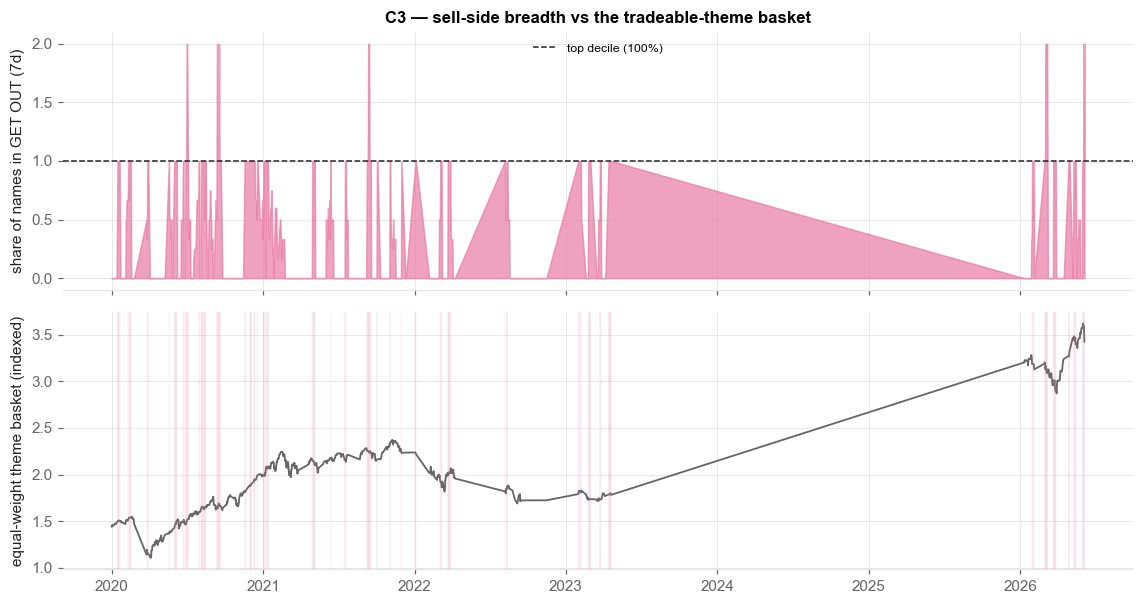

In [18]:
# daily measurable universe (candidate rows) and fired-in-trailing-7d
all_alerts_out = [(n, a) for n, al in prod_out["alerts_by_name"].items()
                  for a in al]
alert_df = pd.DataFrame(all_alerts_out, columns=["name", "date"])
uni = (scored_out.groupby("date")["name"].nunique()
       .rename("measurable"))
fired = pd.Series(0.0, index=uni.index)
for _, r in alert_df.iterrows():
    win = pd.date_range(r["date"], r["date"] + pd.Timedelta(days=6))
    fired.loc[fired.index.isin(win)] += 1
breadth = (fired / uni.clip(lower=1)).dropna()

theme_syms = sorted({sym_by[n] for n in kind_by if kind_by[n] == "theme"
                     and n in sym_by})
basket = pd.concat([pxd[s].pct_change() for s in theme_syms if s in pxd],
                   axis=1, sort=False).mean(axis=1)
bket_fwd21 = ((1 + basket).rolling(21).apply(np.prod, raw=True) - 1) \
    .shift(-21).reindex(breadth.index)

q90 = breadth.quantile(0.9)
hi_days = breadth[breadth >= q90].index
lo_days = breadth[breadth < q90].index
m_hi = float(bket_fwd21.loc[hi_days].median())
m_lo = float(bket_fwd21.loc[lo_days].median())

# monthly-block bootstrap (days are serially dependent - resample months)
mb = pd.DataFrame({"breadth": breadth, "fwd": bket_fwd21}).dropna()
mb["month"] = mb.index.to_period("M")
months = mb["month"].unique()
rng = np.random.default_rng(SEED)
diffs = []
for _ in range(500):
    pick = rng.choice(months, size=len(months), replace=True)
    smp = pd.concat([mb[mb["month"] == m_] for m_ in pick])
    h_ = smp[smp["breadth"] >= q90]["fwd"]
    l_ = smp[smp["breadth"] < q90]["fwd"]
    if len(h_) > 5 and len(l_) > 5:
        diffs.append(h_.median() - l_.median())
c3_ci = ([float(np.percentile(diffs, 5)), float(np.percentile(diffs, 95))]
         if diffs else [np.nan, np.nan])
c3_pass = bool(c3_ci[1] < 0)
print(f"C3: basket median fwd-21d on top-decile breadth days {m_hi:+.3f} "
      f"vs other days {m_lo:+.3f}; diff 90% block CI "
      f"[{c3_ci[0]:+.3f}, {c3_ci[1]:+.3f}] -> "
      f"{'RISK-OFF condition VALID' if c3_pass else 'not separable at 90%'}")

fig, axes = plt.subplots(2, 1, figsize=(10.5, 5.6), sharex=True)
axes[0].fill_between(breadth.index, breadth.values, color=C3, alpha=0.7)
axes[0].axhline(q90, color=INK, ls="--", lw=1,
                label=f"top decile ({q90:.0%})")
axes[0].set_ylabel("share of names in GET OUT (7d)")
axes[0].set_title("C3 — sell-side breadth vs the tradeable-theme basket")
axes[0].legend(frameon=False, fontsize=8)
bket = pd.concat([pxd[s] / pxd[s].iloc[0] for s in theme_syms
                  if s in pxd and len(pxd[s])], axis=1, sort=False)\
    .mean(axis=1)
axes[1].plot(bket.reindex(breadth.index).index,
             bket.reindex(breadth.index).values, color=MUTED, lw=1.2)
for d in hi_days:
    axes[1].axvline(d, color=C3, alpha=0.08, lw=1)
axes[1].set_ylabel("equal-weight theme basket (indexed)")
for a in axes:
    despine(a)
plt.tight_layout(); plt.show()

## Watch items (recorded, with a pre-stated re-test trigger)

Two challengers LOST under the adoption rule but finished close enough
that the honest record is "watch", not "forget". Both re-test
automatically at the next `--research` pass (year rollover), and the
rule they must then beat is the same one written above.

* **B3 logistic-weighted GET OUT**: 30/122 captured vs 24 shipped,
  FA 37 vs 39, median warning 14.5d vs 8d — but the paired capture
  gain CI [−1, +11] still touches zero, and the project's parsimony
  rule (NB03) requires a learner to beat the rules OUTSIDE noise, not
  tie. One more year of episodes will either clear the CI or expose
  the gain as noise. Nothing ships on a CI that includes zero.
* **B1 per-kind thresholds**: capture RATE 0.204 vs 0.197 with false
  alarms HALVED (16 vs 39; 0.102/instr-yr — inside half the budget) —
  but 9 fewer scoreable detectable episodes (single-name years drop
  out of the per-kind walk-forward for lack of training positives),
  so the comparison is not matched and absolute captures fell 24→23.
  As single-name history accrues, this becomes the natural refinement.

## Verdicts & record

In [19]:
verdict = {
    "part_a_operating_point": op_stats,
    "part_a_car21": car_stats,
    "part_a_overlay": overlay_tbl.to_dict(orient="records"),
    "part_b": {"table": exp_tbl.to_dict(orient="records"),
               "smoothing_sweep": sw.to_dict(orient="records"),
               "run_rule": rr.to_dict(orient="records"),
               "adopted": adopted_b},
    "part_c": {"c1_intensity_tier": {"table": tier_tbl.reset_index()
                                     .to_dict(orient="records"),
                                     "uplift_ci90": c1_ci,
                                     "adopted": c1_pass},
               "c2_get_in_tier": {"uplift_ci90": io_ci_in,
                                  "adopted": c2_pass},
               "c3_breadth_risk_off": {"median_fwd21_high": m_hi,
                                       "median_fwd21_other": m_lo,
                                       "diff_ci90": c3_ci,
                                       "top_decile_cut": float(q90),
                                       "adopted": c3_pass}},
    "watch_items": ["B3 logistic-weighted GET OUT (30 vs 24 captures, "
                    "gain CI [-1,+11] touches zero - re-test at year "
                    "rollover)",
                    "B1 per-kind thresholds (FA halved at ~equal capture "
                    "rate, unmatched years - re-test as singles history "
                    "accrues)"],
}
with open(RESEARCH_DIR / "nb07_performance_battery.json", "w") as f:
    json.dump(verdict, f, indent=1, default=str)
print("saved nb07_performance_battery.json")
print(f"total runtime {time.time()-t0:.0f}s")

saved nb07_performance_battery.json
total runtime 155s


## References

* Chan (2026). *Predicting influence and stock movements from social
  media structure.* M.Eng thesis — the project's methodological spine
  (AP/AUROC under imbalance, cluster bootstrap, pre-stated criteria).
* MacKinlay, A.C. (1997). "Event Studies in Economics and Finance."
  *Journal of Economic Literature* 35(1) — CAR methodology (A4).
* Grinold, R. & Kahn, R. (2000). *Active Portfolio Management* —
  information coefficient (A2).
* Page, E.S. (1954). "Continuous Inspection Schemes." *Biometrika* —
  detection delay vs false alarms (A3); Poor & Hadjiliadis (2009),
  *Quickest Detection*, Cambridge UP.
* Davis, J. & Goadrich, M. (2006). "The Relationship Between
  Precision-Recall and ROC Curves." *ICML* — PR under imbalance (A1);
  Saito & Rehmsmeier (2015), *PLOS ONE* 10(3).
* Chicco, D. & Jurman, G. (2020). "The advantages of the Matthews
  correlation coefficient." *BMC Genomics* 21:6 — MCC (A1).
* Murphy, A.H. & Winkler, R.L. (1977). "Reliability of Subjective
  Probability Forecasts." *JRSS C* — reliability diagrams (A5).
* Sharpe, W.F. (1966); Sortino, F. & Price, L. (1994) — overlay risk
  ratios (A6).
* Western Electric Co. (1956). *Statistical Quality Control
  Handbook* — run rules (B4).